In [24]:
import pandas as pd
import numpy as np
import statistics

# Summary_statistics

Types of statistics:
1. Descriptive statistics: describe & summarise data at had (population data)
2. Inferential statistics: uses sample data to describe & summarise 

Types of Data:
1. Numerical(quantitative): continuous data(measured), discrete(counted)
2. Categorical(qualitative): nominal(no order is follwed), ordinal(has ordering)


### Measures of center 
1. Mean
2. Median - 50% is lower and 50% is higher, sort and take the median
3. Mode - most frequent value

In [3]:
food = pd.read_csv(r"C:\Users\vshnu\OneDrive\Desktop\Vishnuperson\RE\aspire_\learn\Datacamp\2_Into_statistics.ipynb\food_consumption.csv")

In [4]:
food.head(3)

,Unnamed: 0,country,food_category,consumption,co2_emission
0,1,Argentina,pork,10.51,37.20
1,2,Argentina,poultry,38.66,41.53
2,3,Argentina,beef,55.48,1712.00


In [ ]:
#mean
np.mean(food["consumption"])

np.float64(28.1104055944056)

In [60]:
q = food[1]
q

KeyError: 1

In [45]:
#median
food["consumption"].count()
#1430
#1430/2 = 715

print(food["consumption"].sort_values().iloc[715])
print(np.median(food["consumption"]))

n = len(food["consumption"])
n

8.89
8.89


1430

In [ ]:
sorted_data = np.sort(food["consumption"])  # Sort the data in ascending order
n = len(sorted_data)  # Total number of data points

# Calculate Q2 (Median)
if n % 2 == 1:  # If odd, the median is the middle element
    q2 = sorted_data[n // 2]
else:  # If even, the median is the average of the two middle elements
    q2 = (sorted_data[n // 2 - 1] + sorted_data[n // 2]) / 2

print("Q2 value (Median):", q2)  # Q2 value


In [47]:
q2 = food[n // 2]
q2

KeyError: 715

In [ ]:
if n % 2 == 0:
    

In [25]:
#mode
print(food["co2_emission"].value_counts())
print(statistics.mode(food["co2_emission"]))


co2_emission
0.00      44
0.02      15
0.01      11
0.04       6
0.05       5
          ..
1.66       1
132.19     1
9.86       1
5.33       1
7.82       1
Name: count, Length: 1183, dtype: int64
0.0


#which centre to use?

for a normal distribution - > mean

for left or right skewed - > median


In [ ]:
# Subset for food_category equals rice
rice_consumption = food_consumption[food_consumption['food_category'] == 'rice']

# Calculate mean and median of co2_emission with .agg()
print(rice_consumption["co2_emission"].agg([np.mean,np.median]))

## Measures of spread

1. variance: calculate difference of each number from its mean, square that distance and get n-1 divide sum of squ.distance by n-1
2. standard deviation - sqrt of variance, they penalise more on longer distance
3. mean standar deviation - mean - values and absolute sum of those distances, they are penalise every distance equallyt
4. Q1, Q3
5. interquartile range (q3-Q1) or height of the box plot

quantiles
- splitting data.
1. by 50% - median
2. 25% - Q1, 50% - Q2, 75%- Q3, 100% - shows the value in that split.

## outlier

x < q1 - 1.5 IQR
x > q3 + 1.5 IQR

In [27]:
food.head(3)

,Unnamed: 0,country,food_category,consumption,co2_emission
0,1,Argentina,pork,10.51,37.20
1,2,Argentina,poultry,38.66,41.53
2,3,Argentina,beef,55.48,1712.00


In [ ]:
## 1. Variance

a = food["consumption"] - np.mean(food["consumption"])
b = a**2
c = food["consumption"].count()
c
var = sum(b)/c 
var

# 2. std
std = np.sqrt(var)
std

# 3. mean deviation
d = np.abs(a)
e = sum(d)
msd = e/c
msd



1430


In [107]:
#4. Q1
a = food["consumption"].sort_index()
a
n = len(a)
lower_half = a[:n//2]

lower_half = lower_half.sort_index()
lower_half 

q1n = len(lower_half)
q1n 

if q1n%2==0:
    q1 = (lower_half.iloc[(q1n-1)//2] + lower_half.iloc[q1n//2])/2
else:
    q1 = lower_half.iloc[q1n//2]

print(q1)

11.69


In [101]:
#q3

upper_half = a[n//2:]
upper_half

q3n = len(upper_half)
q3n


715

In [108]:
if q3n%2==0:
    q3 = (upper_half.iloc[(q3n-1)//2] + upper_half.iloc[q3n//2])/2
else:
    q3 = upper_half.iloc[q3n//2]

print(q3)

1.75


In [ ]:
#by formula

# Print variance and sd of co2_emission for each food_category
print(food_consumption.groupby('food_category')['co2_emission'].agg([np.var, np.std]))

# Create histogram of co2_emission for food_category 'beef'
food_consumption[food_consumption['food_category'] == 'beef']['co2_emission'].hist()
plt.show()

# Create histogram of co2_emission for food_category 'eggs'
food_consumption[food_consumption['food_category'] == 'eggs']['co2_emission'].hist()
plt.show()



In [105]:
print(np.quantile(food["consumption"],[0.25,0.75]))

[ 2.365  28.1325]


In [ ]:
# Calculate total co2_emission per country: emissions_by_country
emissions_by_country = food_consumption.groupby('country')['co2_emission'].sum()

# Compute the first and third quantiles and IQR of emissions_by_country
q1 = np.quantile(emissions_by_country, 0.25)
q3 = np.quantile(emissions_by_country, 0.75)
iqr = q3 - q1

# Calculate the lower and upper cutoffs for outliers
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

# Subset emissions_by_country to find outliers
outliers = emissions_by_country[(emissions_by_country<lower)|(emissions_by_country>upper)]
print(outliers)

# Random Numbers and Probability Distribution & CLT

1. Probability an event will happen - p(x) = #ways x can happen/#possible outcomes
2. sampling with & without replacement
3. two events are independant if probability of first event is not affected by the outcome of 2nd event, 
4. dependant - vv

In [ ]:
# Set random seed
np.random.seed(24)

# Sample 5 deals with replacement
sample_with_replacement = amir_deals.sample(5, replace=True)
print(sample_with_replacement)

Law of large number: as the size of sample increases, the sample mean will approach the expected values


## Continous Distribution

In [ ]:
#constinous uniform distribution

# Min and max wait times for back-up that happens every 30 min
min_time = 0
max_time = 30

# Import uniform from scipy.stats
from scipy.stats import uniform

# Calculate probability of waiting 10-20 mins
prob_between_10_and_20 = uniform.cdf(20,0,30)-uniform.cdf(10,0,30)
print(prob_between_10_and_20)

In [112]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
    --------------------------------------- 0.5/41.0 MB 3.5 MB/s eta 0:00:12
   - -------------------------------------- 1.3/41.0 MB 3.8 MB/s eta 0:00:11
   - -------------------------------------- 1.8/41.0 MB 3.4 MB/s eta 0:00:12
   -- ------------------------------------- 2.4/41.0 MB 3.2 MB/s eta 0:00:13
   -- ------------------------------------- 2.9/41.0 MB 3.0 MB/s eta 0:00:13
   --- ------------------------------------ 3.4/41.0 MB 2.7 MB/s eta 0:00:14
   --- ------------------------------------ 3.9/41.0 MB 2.8 MB/s eta 0:00:14
   ---- ----------------------------------- 5.0/41.0 MB 3.0 MB/s eta 0:00:12
   ----- ---------------------------------- 6.0/41.0 MB 3.2 MB/s eta 0:00:11
   ------ --------------------------------- 6.8/41.0 MB 3.3 MB/s eta 0:00:11
   ------- -------------------------------- 7.9/41.0 MB 3.4 MB/s eta 0:00:10
   --


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
import matplotlib.pyplot as plt

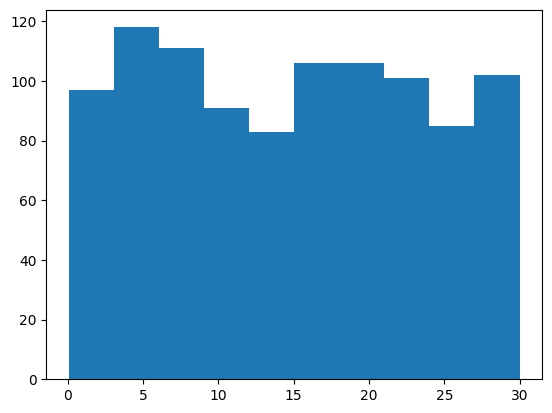

In [115]:
## creating a random variables in continous uniform distribution


# Set random seed to 334
np.random.seed(334)

# Import uniform
from scipy.stats import uniform

# Generate 1000 wait times between 0 and 30 mins
wait_times = uniform.rvs(0, 30, size=1000)

# Create a histogram of simulated times and show plot
plt.hist(wait_times)
plt.show()

## Binomial distribution

Takes success /failure with multiple trials and different porbabilities. 

we use scipy, binom.rvs(num_of_coins, prob of successs, size=#of trailes)

### Binomial distribution is a probability distribution of number of successs in a sequences of independent trials

takes n, p

n --> number of trials
p --> probability of successs

### to get pmf of a certain number
use,

binom.pmf(7,10,0.5) --> binom.pmf(num heads, num trials, prob of heads)

### less then or equal to 
binom.cdf(7,10,0.5) --> binom.pmf(num heads, num trials, prob of heads)

In [ ]:
# Import binom from scipy.stats
from scipy.stats import binom

# Set random seed to 10
np.random.seed(10)

# Simulate a single deal
print(binom.rvs(1, 0.3, size=1))

# Simulate 1 week of 3 deals
print(binom.rvs(3,0.3,size=1))

# Simulate 52 weeks of 3 deals
deals = binom.rvs(3,0.3,size=52)

# Print mean deals won per week
print(np.mean(deals))

In [ ]:
# Probability of closing 3 out of 3 deals
prob_3 = binom.pmf(3,3,0.3)

print(prob_3)

# Probability of closing <= 1 deal out of 3 deals
prob_less_than_or_equal_1 = binom.cdf(1,3,0.3)

print(prob_less_than_or_equal_1)


# Probability of closing > 1 deal out of 3 deals
prob_greater_than_1 = 1 - binom.cdf(1,3,0.3)

print(prob_greater_than_1)

In [ ]:
#### Expected value

# Expected number won with 30% win rate
won_30pct = 3 * 0.3
print(won_30pct)

# Expected number won with 25% win rate
won_25pct = 3 * 0.25
print(won_25pct)

# Expected number won with 35% win rate
won_35pct = 3 *0.35
print(won_35pct)

## Normal distribution

1. curve never hits 0
2. standard normal distribution - mean = 0, std = 1, 68% area falls within 1 std, 95% within 2 std of mean. 99.7% bw 3 std. 


norm.cdf(num_of_interest, mean, std)

### get num_of_interest given porbability
norm.ppf(percent, mean, std)

#### rvs
norm.rvs(mean, std, size=10)

In [ ]:
# Histogram of amount with 10 bins and show plot
amir_deals["amount"].hist(bins=10)
plt.show()


# Probability of deal < 7500
prob_less_7500 = norm.cdf(7500,5000,2000)
print(prob_less_7500)

# Probability of deal > 1000
prob_over_1000 = 1 - norm.cdf(1000,5000,2000)
print(prob_over_1000)

# Probability of deal between 3000 and 7000
prob_3000_to_7000 = norm.cdf(7000,5000,2000) - norm.cdf(3000,5000,2000) 
print(prob_3000_to_7000)

# Calculate amount that 25% of deals will be less than
pct_25 = norm.ppf(0.25,5000,2000)

print(pct_25)

In [ ]:
# Calculate new average amount
new_mean = 5000 + 5000*0.20

# Calculate new standard deviation
new_sd = 2000 + 2000*0.3

# Simulate 36 new sales
new_sales = norm.rvs(new_mean,new_sd, size=36)

# Create histogram and show
plt.hist(new_sales)
plt.show()

## Central limit theorem



In [ ]:
## lets roll a die 5 times and take their sample mean. and do this for 20 times and 100 times

die = pd.Series([1,2,3,4,5,6])
sample_means = []

for i in range(20):
    samp_5 = die.sample(5, replace=True)
    sample_means.append(np.mean(samp_5))


print(sample_means)


[np.float64(4.8), np.float64(2.6), np.float64(4.2), np.float64(3.6), np.float64(4.6), np.float64(3.0), np.float64(2.6), np.float64(3.2), np.float64(3.4), np.float64(4.2), np.float64(3.6), np.float64(5.0), np.float64(3.8), np.float64(4.4), np.float64(3.4), np.float64(4.4), np.float64(3.0), np.float64(3.6), np.float64(2.8), np.float64(4.2)]


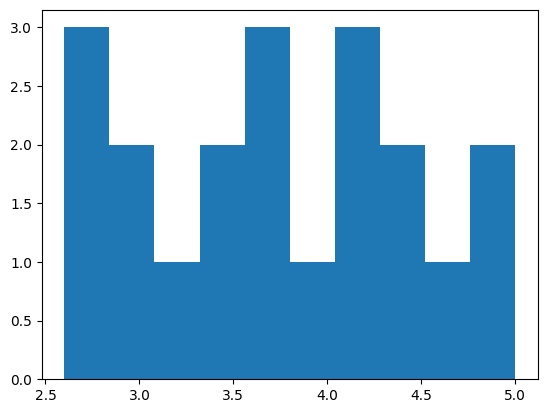

In [122]:
plt.hist(sample_means)
plt.show()

In [123]:
#simulate 5 play sessison, 100 times

sample_means = []

for i in range(100):
    play_5 = die.sample(5, replace=True)
    sample_means.append(np.mean(play_5))

print(sample_means)

[np.float64(3.2), np.float64(3.6), np.float64(3.0), np.float64(4.2), np.float64(2.8), np.float64(2.8), np.float64(3.6), np.float64(3.2), np.float64(3.2), np.float64(2.4), np.float64(3.2), np.float64(4.0), np.float64(3.4), np.float64(2.8), np.float64(4.2), np.float64(2.6), np.float64(3.0), np.float64(2.6), np.float64(2.0), np.float64(2.6), np.float64(3.0), np.float64(2.8), np.float64(4.2), np.float64(3.0), np.float64(2.6), np.float64(2.8), np.float64(4.0), np.float64(4.0), np.float64(3.0), np.float64(4.0), np.float64(5.6), np.float64(2.2), np.float64(3.6), np.float64(4.4), np.float64(3.2), np.float64(3.6), np.float64(3.6), np.float64(2.6), np.float64(4.0), np.float64(4.4), np.float64(3.8), np.float64(4.6), np.float64(4.4), np.float64(3.6), np.float64(4.0), np.float64(4.2), np.float64(3.0), np.float64(4.6), np.float64(3.8), np.float64(2.2), np.float64(3.8), np.float64(4.6), np.float64(2.8), np.float64(3.8), np.float64(3.8), np.float64(3.4), np.float64(3.6), np.float64(4.6), np.float64(3.

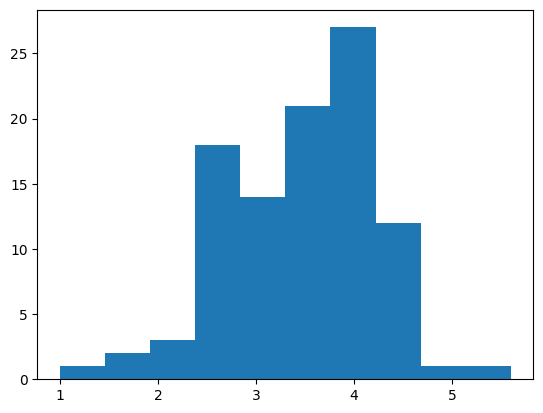

In [124]:
plt.hist(sample_means)
plt.show()

In [ ]:
# Set seed to 104
np.random.seed(104)

# Sample 20 num_users with replacement from amir_deals and take mean
samp_20 = amir_deals['num_users'].sample(20, replace=True)
np.mean(samp_20)

sample_means = []
# Loop 100 times
for i in range(100):
  # Take sample of 20 num_users
  samp_20 = amir_deals['num_users'].sample(20, replace=True)
  # Calculate mean of samp_20
  samp_20_mean = np.mean(samp_20)
  # Append samp_20_mean to sample_means
  sample_means.append(samp_20_mean)
  
print(sample_means)

In [ ]:
# Set seed to 104
np.random.seed(104)

sample_means = []
# Loop 100 times
for i in range(100):
  # Take sample of 20 num_users
  samp_20 = amir_deals['num_users'].sample(20, replace=True)
  # Calculate mean of samp_20
  samp_20_mean = np.mean(samp_20)
  # Append samp_20_mean to sample_means
  sample_means.append(samp_20_mean)
  
# Convert to Series and plot histogram
sample_means_series = pd.Series(sample_means)
sample_means_series.hist()
# Show plot
plt.show()

In [ ]:
# Set seed to 321
np.random.seed(321)

sample_means = []
# Loop 30 times to take 30 means
for i in range(30):
  # Take sample of size 20 from num_users col of all_deals with replacement
  cur_sample = all_deals['num_users'].sample(20,replace=True)
  # Take mean of cur_sample
  cur_mean = np.mean(cur_sample)
  # Append cur_mean to sample_means
  sample_means.append(cur_mean)

# Print mean of sample_means
print(np.mean(sample_means))

# Print mean of num_users in amir_deals
print(np.mean(amir_deals["num_users"]))

## Poisson Distribution

events appear to happen at a certain rate,  but completely random,
ex: num of pet adaptoed, num of people arriving at restaurant, eqrthquake

--> probability of some # of events happending at a fixed period of time

lembda - avg numebe rof events. E(X)

poisson.pmf(5,8) 8 is mean

poisson.csdf(5,8) 8 is mean - 5 is proba <= 5 

#### sample
poisson.rvs(8, size=10) ; 10 different weeks, 

In [ ]:
## probablity of amir responsifng to different number of leads per day

# Import poisson from scipy.stats
from scipy.stats import poisson

# Probability of 5 responses
prob_5 = poisson.pmf(5,4)

print(prob_5)

# Import poisson from scipy.stats
from scipy.stats import poisson

# Probability of 2 or fewer responses
prob_2_or_less = poisson.cdf(2,4)

print(prob_2_or_less)

# Probability of > 10 responses
prob_over_10 = 1 - poisson.cdf(10,4)

print(prob_over_10)

## Few more

1. Exponential: probability of time between poisson events
2. e(x) = 1/lambda

### t -sidtribution
tails are thickers. obs fall further from mean.
more the df, more it is close to being normal dist.

### log-normal
skwed normal. 


In [ ]:
# Import expon from scipy.stats
from scipy.stats import expon

# Print probability response takes < 1 hour
print(expon.cdf(1, scale=2.5))


# Print probability response takes > 4 hours
print(1- expon.cdf(4,scale=2.5))

# Print probability response takes 3-4 hours
print(expon.cdf(4,scale=2.5) - expon.cdf(3,scale=2.5))

# Correlation & Experimental Design

### Relationship bw two numbers 

x - independat variable, y- dependant / response variable.

## Correlation coeffcient
(-1,1) shows realition in number. 

### Correlation coefficient & Scatter plot with & without trend line using seaborn

In [ ]:
# Create a scatterplot of happiness_score vs. life_exp and show
sns.scatterplot(x="life_exp",y="happiness_score",data=world_happiness)

# Show plot
plt.show()


# Create scatterplot of happiness_score vs life_exp with trendline
sns.lmplot(x="life_exp",y="happiness_score",data=world_happiness,ci=None)

# Show plot
plt.show()


# Correlation between life_exp and happiness_score
cor = world_happiness["life_exp"].corr(world_happiness["happiness_score"])

print(cor)

### Correlation caveatos

it is only for linear relationships
if its skewed, use logtransaformation



In [ ]:
# Create log_gdp_per_cap column
world_happiness['log_gdp_per_cap'] = np.log(world_happiness["gdp_per_cap"])

# Scatterplot of happiness_score vs. log_gdp_per_cap
sns.scatterplot(x="log_gdp_per_cap",y="happiness_score", data=world_happiness)

# Calculate correlation
cor = world_happiness['log_gdp_per_cap'].corr(world_happiness['happiness_score'])
plt.show()
print(cor)

### Design of experiments

answer: what is the effect of treatment on resposne

treatment: indep variable/ explanatory
response: dep variable/ response

Controlled experiment - treatment vs controlled

ways to limit bias
1. randomised controled trial
2. placebo
3. double blind trial